# Runtime

Copy page

​
Overview

LangChain’s create_agent runs on LangGraph’s runtime under the hood.

LangGraph exposes a Runtime object with the following information:

Context: static information like user id, db connections, or other dependencies for an agent invocation

Store: a BaseStore instance used for long-term memory

Stream writer: an object used for streaming information via the "custom" stream mode

Execution info: identity and retry information for the current execution (thread ID, run ID, attempt number)

Server info: server-specific metadata when running on LangGraph Server (assistant ID, graph ID, authenticated user)

In [ ]:
import os

from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
import pprint
from langchain.tools import tool

from langchain.chat_models import init_chat_model
from rich import print as rprint

In [3]:
model_free = init_chat_model("openai/gpt-oss-20b",
                        api_key=os.environ["GROQ_API_KEY"],
                        model_provider="groq",
                        # base_url="https://api.groq.com/openai/v1",
                        max_tokens=10000, temperature=0.0)

model_basic = init_chat_model("openrouter/free",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=1000, temperature=0.0)

model_medium = init_chat_model("openai/gpt-5.6-luna",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)

model_advanced = init_chat_model("openai/gpt-5.6-luna-pro",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)

model_safety = init_chat_model("nvidia/nemotron-3.5-content-safety:free",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)



In [11]:
from dataclasses import dataclass

from langchain.agents import create_agent

from langgraph.store.memory import InMemoryStore 
@dataclass
class Context:
    user_name: str

agent = create_agent(
    model=model_advanced,
    tools=[],
    store = InMemoryStore(),
    context_schema=Context ,
)


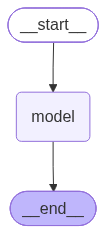

In [12]:
agent

In [13]:

agent.invoke(
    {"messages": [{"role": "user", "content": "My name is Sunj"}]},
    context=Context(user_name="Sunj")
)

{'messages': [HumanMessage(content='My name is Sunj', additional_kwargs={}, response_metadata={}, id='d1d78747-3a4d-4162-9cf5-06b54e24e24d'),
  AIMessage(content='Nice to meet you, Sunj! How can I help you today?', additional_kwargs={}, response_metadata={'model_name': 'openai/gpt-5.6-luna-pro', 'id': 'gen-1787156165-p931mtCWMz60CcMQ2uiP', 'created': 1787156165, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter', 'cost': 0.00020384, 'cost_details': {'upstream_inference_completions_cost': 0.0001296, 'upstream_inference_prompt_cost': 7.424e-05, 'upstream_inference_cost': 0.00020384}}, id='lc_run--01a01ace-ef10-78b0-b7f7-253a362bed86-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1561, 'output_tokens': 108, 'total_tokens': 1669, 'input_token_details': {'cache_read': 1322, 'cache_creation': 0}, 'output_token_details': {'reasoning': 34}})]}

## Inside tools

You can access the runtime information inside tools to:

Access the context

Read or write long-term memory

Write to the custom stream (ex, tool progress / updates)

Use the ToolRuntime parameter to access the Runtime object inside a tool.

In [14]:

from langchain.tools import tool, ToolRuntime  


@tool
def fetch_user_email_preferences(runtime: ToolRuntime[Context]) -> str:
    """Fetch the user's email preferences from the store."""
    user_id = runtime.context.user_id  
    rprint(user_id)

    preferences: str = "The user prefers you to write a brief and polite email."
    if runtime.store:
        if memory := runtime.store.get(("users",), user_id):
            preferences = memory.value["preferences"]

    return preferences

In [17]:
agent1 = create_agent(
    model=model_advanced,
    tools=[fetch_user_email_preferences],
    store = InMemoryStore(),
    context_schema=Context ,
)

In [18]:

agent1.invoke(
    {"messages": [{"role": "user", "content": "Fetch my mail"}]},
    context=Context(user_name="Sunj")
)

{'messages': [HumanMessage(content='Fetch my mail', additional_kwargs={}, response_metadata={}, id='fdef739f-b9fe-46ba-8131-3dbe97b4b4bb'),
  AIMessage(content='I can’t access or fetch your email in this chat.', additional_kwargs={'reasoning_content': '**Clarifying email tools**\n\nI think we only need the email preferences tool, not the mail fetch tool. I should probably explain why I can\'t fetch mail since there might be a mismatch with the "fetch my mail" request. It seems fetching preferences isn’t really relevant, so I should just say that I’m unable to do that. It’s important to keep things clear and straightforward for the user!', 'reasoning_details': [{'summary': '**Clarifying email tools**\n\nI think we only need the email preferences tool, not the mail fetch tool. I should probably explain why I can\'t fetch mail since there might be a mismatch with the "fetch my mail" request. It seems fetching preferences isn’t really relevant, so I should just say that I’m unable to do th